In [30]:
import cvxpy as cp
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from matplotlib.backends.backend_pdf import PdfPages
from collections import defaultdict

pd.options.display.max_rows=2000
pd.options.display.max_columns=70

plot_dir = "/Users/eric/repos/aud/plots"

remake_plots=False

In [31]:
# Import and prep data
# Data importing stage

# Start with latest (?) cleaned data
cleaned_ema_path = "/Volumes/private/studydata/risk/data_processed/ema/ema.csv"
hourly_labels_path = "/Volumes/private/studydata/risk/data_processed/ema/labels_1hour.csv"
daily_labels_path = "/Volumes/private/studydata/risk/data_processed/ema/labels_1day.csv"
weekly_labels_path = "/Volumes/private/studydata/risk/data_processed/ema/labels_1week.csv"
study_dates_path = "/Volumes/private/studydata/risk/data_processed/ema/study_dates.csv" 

# Data imports
# Ecological momentary assessments
ema_raw = pd.read_csv(cleaned_ema_path,parse_dates=['dttm_obs'],date_parser=lambda x: pd.to_datetime(x, format="%Y-%m-%dT%H:%M:%S",utc=True).tz_convert('US/Central'))
# Data labels
hourly_labels_raw = pd.read_csv(hourly_labels_path,parse_dates=['dttm_label'],date_parser=lambda x: pd.to_datetime(x, format="%Y-%m-%dT%H:%M:%S",utc=True).tz_convert('US/Central'))
daily_labels_raw = pd.read_csv(daily_labels_path,parse_dates=['dttm_label'],date_parser=lambda x: pd.to_datetime(x, format="%Y-%m-%dT%H:%M:%S",utc=True).tz_convert('US/Central'))
weekly_labels_raw = pd.read_csv(weekly_labels_path,parse_dates=['dttm_label'],date_parser=lambda x: pd.to_datetime(x, format="%Y-%m-%dT%H:%M:%S",utc=True).tz_convert('US/Central'))
# Background information about the study dates for each individual
study_dates_raw = pd.read_csv(study_dates_path,parse_dates=['study_start','data_start','study_end','ema_end'],date_parser=lambda x: pd.to_datetime(x, format="%Y-%m-%dT%H:%M:%S",utc=True).tz_convert('US/Central'))

# Path of the raw list of lapses
lapse_list_path = '/Volumes/private/studydata/risk/data_processed/shared/lapses.csv'
# Import and copy the dataframe
lapse_import_raw = pd.read_csv(lapse_list_path,parse_dates=['lapse_start','lapse_end'],date_parser=lambda x: pd.to_datetime(x, format="%Y-%m-%dT%H:%M:%S",utc=True).tz_convert('US/Central'))
lapse_summary_df = lapse_import_raw.drop(['ema_end'],axis=1).join(study_dates_raw.set_index('subid'),on='subid')
# Drop miscellaneous columns and get rid of 'exclude'==True rows
lapse_summary_df.drop(['lapse_start_date','lapse_start_time','lapse_end','lapse_end_time','lapse_end_date','response_id','lapse_cnt'],axis=1,inplace=True)
lapse_summary_df.drop(lapse_summary_df.loc[lapse_summary_df['exclude']==True].index, inplace=True)

# Re-create relevant columns from deprecated processing sequence above
#             lapse_summary_list.append(pd.DataFrame({"subid":id,"lapse_start":start_time,"hour_of_day":start_time.hour,"lapse_duration":delta,"int_lapse_duration":int_delta,
#                                                     "norm_date":start_row.norm_date,"day_of_week":start_row.day_of_week,"day_of_week_num":start_row.day_of_week_num,
#                                                     "time_of_week":start_row.dttm_label.hour/24+start_row.day_of_week_num,"lapse":1},index=[0]))
lapse_summary_df['td_date']=lapse_summary_df.lapse_start.sub(lapse_summary_df.data_start)
lapse_summary_df['norm_date']=lapse_summary_df['td_date'].dt.days+lapse_summary_df['td_date'].dt.seconds/86400
lapse_summary_df['hour_of_day']=lapse_summary_df.apply(lambda row: row.lapse_start.hour,axis=1)
lapse_summary_df['day_of_week']=lapse_summary_df.apply(lambda row: row.lapse_start.day_name(),axis=1)
lapse_summary_df['day_of_week_num']=lapse_summary_df.apply(lambda row: row.lapse_start.weekday(),axis=1)
lapse_summary_df['time_of_week']=lapse_summary_df.apply(lambda row: row.lapse_start.hour/24+row.day_of_week_num,axis=1)

# Final cleanup/drop
lapse_summary_df.rename(columns={'duration':'int_lapse_duration'},inplace=True)
lapse_summary_df.drop(['exclude','ema_1_6','study_start','data_start','study_end','ema_end'],inplace=True,axis=1)

# Take a peek
lapse_summary_df.head()

,subid,lapse_start,int_lapse_duration,source,td_date,norm_date,hour_of_day,day_of_week,day_of_week_num,time_of_week
0,2,2017-04-01 19:00:00-05:00,0.0,ema,8 days 19:00:00,8.791667,19,Saturday,5,5.791667
1,2,2017-04-03 18:00:00-05:00,3.0,ema,10 days 18:00:00,10.750000,18,Monday,0,0.750000
2,2,2017-04-29 20:00:00-05:00,2.0,ema,36 days 20:00:00,36.833333,20,Saturday,5,5.833333
3,2,2017-05-06 20:00:00-05:00,1.0,ema,43 days 20:00:00,43.833333,20,Saturday,5,5.833333
4,2,2017-05-13 11:00:00-05:00,0.0,ema,50 days 11:00:00,50.458333,11,Saturday,5,5.458333


In [32]:
# Start taking a look at EMA responses

# Checking for changes in subid within ema data
def ema_delta_helper(row):
    if row.id_change:
        return 0
    else:
        return (row.norm_date-row.norm_date_s1)*24
    
# Join the relevant study date labels
ema_df = ema_raw.join(study_dates_raw.set_index('subid'),on='subid')
# Drop the folks with no study date information
ema_df.dropna(axis=0,how='any',subset='study_start',inplace=True)

# Sort the information first by subid then datetime
ema_df.sort_values(['subid','dttm_obs'],inplace=True,ignore_index=True)

# Calculate the time-delta between the start of data and datetime label (to normalize for people studied at different times)
ema_df['td_date']=ema_df.dttm_obs.sub(ema_df.data_start)

# Convert the time-delta to an numeric value (in days)
ema_df['norm_date']=ema_df['td_date'].dt.days+ema_df['td_date'].dt.seconds/86400

# Get specifics of time of day/week
ema_df['day_of_week']=ema_df.apply(lambda row: row.dttm_obs.day_name(),axis=1)
ema_df['day_of_week_num']=ema_df.apply(lambda row: row.dttm_obs.weekday(),axis=1)

# New column for identifying subject changes
ema_df['subid_s1']=ema_df.subid.shift(1)
# Apply function to catch subject changes
ema_df['id_change']=ema_df.apply(lambda row: 0 if row.subid==row.subid_s1 else 1,axis=1)
# Get the shifted norm date (mostly deprecated)
ema_df['norm_date_s1']=ema_df.norm_date.shift(1)
# Take the floor of the date to get integer date numbers
ema_df["rounded_date"]=ema_df.apply(lambda row: np.floor(row.norm_date),axis=1)
# Get a numeric time of day
ema_df["time_of_day"]=ema_df.apply(lambda row: (row.norm_date-row.rounded_date)*24,axis=1)
# Take the difference between the norm date and the shifted norm date
ema_df['ema_delta']=ema_df.apply(ema_delta_helper,axis=1)
# Preallocate the EMA index (which EMA of the day) for each row
ema_df["ema_ind"]=np.nan

ema_df.head()

KeyboardInterrupt: 

In [ ]:
# Noticed some weird rows
ema_df.query("norm_date>=100").head()

,dttm_obs,subid,ema_1,ema_1_1,ema_1_2,ema_1_3,ema_1_4,ema_1_5,ema_1_6,ema_2,ema_3,ema_4,ema_5,ema_6,ema_7,ema_8,ema_9,ema_10,ema_type,study_start,data_start,study_end,ema_end,td_date,norm_date,day_of_week,day_of_week_num,subid_s1,id_change,norm_date_s1,rounded_date,time_of_day,ema_delta,ema_ind
15055,2018-11-14 14:23:01-06:00,79,Yes,NaN,NaN,NaN,NaN,NaN,America/Chicago,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,morning,2018-06-23 00:00:00-05:00,2018-06-23 00:00:00-05:00,2018-09-20 00:00:00-05:00,2020-01-13 12:51:48-06:00,144 days 15:23:01,144.640984,Wednesday,2,79.0,0,89.743681,144.0,15.383611,1317.535278,NaN
15056,2020-01-07 16:59:08-06:00,79,No,NaN,NaN,NaN,NaN,NaN,NaN,3.0,1.0,8.0,4.0,8.0,8.0,4.0,4.0,4.0,morning,2018-06-23 00:00:00-05:00,2018-06-23 00:00:00-05:00,2018-09-20 00:00:00-05:00,2020-01-13 12:51:48-06:00,563 days 17:59:08,563.749398,Tuesday,1,79.0,0,144.640984,563.0,17.985556,10058.601944,NaN
15057,2020-01-13 12:53:23-06:00,79,No,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,2.0,2.0,10.0,5.0,5.0,4.0,4.0,morning,2018-06-23 00:00:00-05:00,2018-06-23 00:00:00-05:00,2018-09-20 00:00:00-05:00,2020-01-13 12:51:48-06:00,569 days 13:53:23,569.578738,Monday,0,79.0,0,563.749398,569.0,13.889722,139.904167,NaN
23593,2020-04-24 12:27:33-05:00,137,Yes,11-03-2018,3 AM,11-03-2018,5 AM,Uncertain,America/Chicago,10.0,6.0,5.0,8.0,8.0,8.0,8.0,9.0,9.0,morning,2018-10-02 00:00:00-05:00,2018-10-02 00:00:00-05:00,2018-12-30 00:00:00-06:00,2020-04-24 12:26:47-05:00,570 days 12:27:33,570.519132,Friday,4,137.0,0,90.013889,570.0,12.459167,11532.125833,NaN


In [ ]:
# Drop these rows
drop_idx = ema_df.query("norm_date>=100").index.values.tolist()
ema_df.drop(drop_idx,inplace=True)
ema_df.query("norm_date>=100").head()
ema_df.reset_index()
None

In [ ]:
# Create individual summary dataframe (each entry is an individual, all individuals accounted for)

# Count up the lapses
total_lapse_count = lapse_summary_df.shape[0]
# Initialize a list for collecting entries
individual_summary_list = []
# Gather up all the individuals in the lapse dataframe
lapsed_individuals = lapse_summary_df.subid.unique()

# Loop over individuals in the dataset
subids = hourly_labels_raw.subid.unique()
for id in subids:
    # If there is record of a lapse, get count, avg duration, stdv of duration
    if id in lapsed_individuals:
        lapse_count = lapse_summary_df.groupby(['subid']).subid.count().loc[id]
        fractional_lapse_contribution = lapse_count/total_lapse_count
        lapse_duration_avg = lapse_summary_df.groupby(['subid']).int_lapse_duration.mean().loc[id]
        lapse_duration_std = lapse_summary_df.groupby(['subid']).int_lapse_duration.std().loc[id]
    # If the individual does not appear in the lapse dataframe, log 0s
    else:
        lapse_count = 0
        fractional_lapse_contribution=0
        lapse_duration_avg = 0
        lapse_duration_std = 0
    # Gather information about this individual and append to the dataframe list
    temp_df = pd.DataFrame({'subid':id,'lapse_count':lapse_count,'fractional_lapse_contribution':fractional_lapse_contribution,'lapse_duration_avg':lapse_duration_avg,'lapse_duration_std':lapse_duration_std},index=[0])
    individual_summary_list.append(temp_df)

# Build the final dataframe from the list of dataframes (each entry is an individual)
individual_summary_df = pd.concat(individual_summary_list,ignore_index=True)
print("Dataframe containing information about the lapse behavior of each individual:")
individual_summary_df.head()

Dataframe containing information about the lapse behavior of each individual:


,subid,lapse_count,fractional_lapse_contribution,lapse_duration_avg,lapse_duration_std
0,1,0,0.000000,0.000000,0.000000
1,2,5,0.004859,1.200000,1.303840
2,3,9,0.008746,0.222222,0.440959
3,5,0,0.000000,0.000000,0.000000
4,6,0,0.000000,0.000000,0.000000


In [ ]:
# Helper function for classifying individuals based on their lapse count
# Should refactor this to make it more flexible for different cutoffs
def lapse_id_classifier_helper(row,cutoffs):
    # If the person has no lapses, they are classified as a 0
    if row.lapse_count == 0:
        return 0
    # Cases for when they do lapse, currently divided into 4 quartiles
    else:
        if row.lapse_count <= cutoffs[0]:
            return 1
        elif row.lapse_count <= cutoffs[1]:
            return 2
        elif row.lapse_count <= cutoffs[2]:
            return 3
        else:
            return 4
        
# Synthesize information about the number of lapses for further breakdowns in the subsequent plots
# Want to be able to categorize lapses as coming from individuals in upper 50% vs. lower 50%
lapse_dist = individual_summary_df.query("lapse_count!=0").lapse_count.to_numpy()

# Start by dividing people into quartiles
thresholds = np.quantile(lapse_dist,[0.25,0.5,0.75])
print("Lapse quartile thresholds (Q1, Q2, Q3): {}".format(thresholds))
print("Note: Non-lapsers assigned '0' label, lapsers assigned labels 1-4")
# Get the quartile of each individual
individual_summary_df['id_type']=individual_summary_df.apply(lambda row: lapse_id_classifier_helper(row,thresholds),axis=1)
print("Show that the id_type number has been added to each individual:")
display(individual_summary_df.iloc[0:10])

# Now add this information back into the lapse_summary_df dataframe (so each lapse can also be grouped by the type of individual)
lapse_summary_df = pd.merge(lapse_summary_df,individual_summary_df[['subid','id_type']],how='left',on='subid')
print("Show that the id_type number has been added to each lapse (tied back to the subid)")
display(lapse_summary_df.iloc[0:5])

Lapse quartile thresholds (Q1, Q2, Q3): [ 2.  7. 18.]
Note: Non-lapsers assigned '0' label, lapsers assigned labels 1-4
Show that the id_type number has been added to each individual:


,subid,lapse_count,fractional_lapse_contribution,lapse_duration_avg,lapse_duration_std,id_type
0,1,0,0.000000,0.000000,0.000000,0
1,2,5,0.004859,1.200000,1.303840,2
2,3,9,0.008746,0.222222,0.440959,3
3,5,0,0.000000,0.000000,0.000000,0
4,6,0,0.000000,0.000000,0.000000,0
5,7,18,0.017493,1.888889,0.963382,3
6,9,0,0.000000,0.000000,0.000000,0
7,10,18,0.017493,2.470588,1.545867,3
8,11,8,0.007775,1.000000,1.195229,3
9,15,0,0.000000,0.000000,0.000000,0


Show that the id_type number has been added to each lapse (tied back to the subid)


,subid,lapse_start,int_lapse_duration,source,td_date,norm_date,hour_of_day,day_of_week,day_of_week_num,time_of_week,id_type
0,2,2017-04-01 19:00:00-05:00,0.0,ema,8 days 19:00:00,8.791667,19,Saturday,5,5.791667,2
1,2,2017-04-03 18:00:00-05:00,3.0,ema,10 days 18:00:00,10.750000,18,Monday,0,0.750000,2
2,2,2017-04-29 20:00:00-05:00,2.0,ema,36 days 20:00:00,36.833333,20,Saturday,5,5.833333,2
3,2,2017-05-06 20:00:00-05:00,1.0,ema,43 days 20:00:00,43.833333,20,Saturday,5,5.833333,2
4,2,2017-05-13 11:00:00-05:00,0.0,ema,50 days 11:00:00,50.458333,11,Saturday,5,5.458333,2


In [ ]:
# Create a day-level dataset (day is labeled 1 if a lapse starts on that day, 0 otherwise)
label_list=[]

# Shift corresponds to a day that starts and ends at 4AM
day_shift = 0.16
# Get the subids from the labels dataset that was originally imported
subids=hourly_labels_raw.subid.unique()
# Loop over the subjects
for id in subids:
    # Identify the day of the week for day 0 for this particular patient
    data_start_day_of_week=study_dates_raw.query("subid==@id").data_start.iloc[0].weekday()
    # Stick to standard 90 day study period
    for day in range(90):
        # Calculate the day of the week based on the day of the week at the beginning of the study
        day_of_week_num=(data_start_day_of_week+day)%7

        # Start time is either 0 (for day zero) or 4AM
        if day!=0:
            start=day+day_shift
        else:
            start=day
        # End of day
        end = day+day_shift+1

        # Gather the entries in the particular (start,end) window
        lapse_count = lapse_summary_df.query("subid==@id & @start<norm_date<@end").shape[0]
        lapse_bool = 1 if lapse_count>=1 else 0

        # Add this information to a dataframe and append to the concatenation list
        temp_df = pd.DataFrame({'subid':id,'day':day,'lapse_count_d0':lapse_count,'lapse_bool_d0':lapse_bool,'day_of_week_num':day_of_week_num},index=[0])
        label_list.append(temp_df)
        
# Create a dataframe from the list
day_labels = pd.concat(label_list,ignore_index=True)
day_labels = pd.merge(day_labels,individual_summary_df[['subid','id_type','lapse_count']],how='left',on='subid')
day_labels = pd.get_dummies(day_labels,columns=['day_of_week_num'],drop_first=True)
day_labels.head()

,subid,day,lapse_count_d0,lapse_bool_d0,id_type,lapse_count,day_of_week_num_1,day_of_week_num_2,day_of_week_num_3,day_of_week_num_4,day_of_week_num_5,day_of_week_num_6
0,1,0,0,0,0,0,0,0,1,0,0,0
1,1,1,0,0,0,0,0,0,0,1,0,0
2,1,2,0,0,0,0,0,0,0,0,1,0
3,1,3,0,0,0,0,0,0,0,0,0,1
4,1,4,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Create additional label columns for shifted days
day_shift = [1,2,3,4,5,6,7,8,9,10,11,12,13,14]
for delta in day_shift:
    col_name = 'lapse_bool_d'+str(delta)
    day_labels[col_name]=day_labels.groupby('subid')['lapse_bool_d0'].shift(-delta)

# Create additional (feature) columns for whether there was a lapse in the last 1, 3, or 5 days
other_shift = [1,2,3,4,5]
for delta in other_shift:
    col_name = 'lapse_bool_minus'+str(delta)
    day_labels[col_name]=day_labels.groupby('subid')['lapse_bool_d0'].shift(delta)
    day_labels[col_name]=day_labels[col_name].fillna(0)

day_labels['minus_1']=day_labels.apply(lambda row: row.lapse_bool_minus1,axis=1)
day_labels['minus_3']=day_labels.apply(lambda row: row.lapse_bool_minus1 or row.lapse_bool_minus2 or row.lapse_bool_minus3,axis=1)
day_labels['minus_5']=day_labels.apply(lambda row: row.lapse_bool_minus1 or row.lapse_bool_minus2 or row.lapse_bool_minus3 or row.lapse_bool_minus4 or row.lapse_bool_minus5,axis=1)
day_labels.drop(labels=['lapse_bool_minus1','lapse_bool_minus2','lapse_bool_minus3','lapse_bool_minus4','lapse_bool_minus5'],axis=1,inplace=True)
day_labels.head()

# Helper function for identifying if there is a lapse within a given week
def calculate_week_lapse(row,shift):
    col_labels = ['lapse_bool_d'+str(i) for i in range(shift,shift+7,1)]
    weekvals = row[col_labels].tolist()
    if np.isnan(weekvals).any():
        return np.nan
    else:
        return max(weekvals)
week_shift = [0,1,2,3,4,5,6,7]   
for shift in week_shift:
    col_name = 'lapse_bool_w'+str(shift)
    day_labels[col_name]=day_labels.apply(lambda row: calculate_week_lapse(row,shift),axis=1)

In [ ]:
# Generate dataframe describing EMA compliance for use in subject selection
ema_compliance_list=[]
for id in day_labels.subid.unique():
    # Get current subjects EMAs
    sub_df = ema_df.query("subid==@id").copy()
    # Total EMAs
    total = sub_df.shape[0]
    # Morning/later EMAs
    morning = sub_df.query("ema_type=='morning'").shape[0]
    later = total-morning
    # Days with EMAs
    morning_day = sub_df.query("ema_type=='morning' & rounded_date<=89 & rounded_date>=0").rounded_date.unique().shape[0]
    morning_day_ind = sub_df.query("ema_type=='morning'").rounded_date.unique()
    later_day = sub_df.query("ema_type=='later'").rounded_date.unique().shape[0]
    temp_df = pd.DataFrame({'subid':id,'total_ema':total,'morning_ema':morning,'later_ema':later,'days_w_morning':morning_day,'days_w_later':later_day,'morning_inds':[morning_day_ind]},index=[0])
    ema_compliance_list.append(temp_df)
# Create a dataframe from the list
ema_compliance = pd.concat(ema_compliance_list,ignore_index=True)
display(ema_compliance.iloc[0:30])

,subid,total_ema,morning_ema,later_ema,days_w_morning,days_w_later,morning_inds
0,1,195,67,128,65,65,"[0.0, 1.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ..."
1,2,286,78,208,78,83,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ..."
2,3,344,89,255,87,89,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ..."
3,5,359,91,268,89,91,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ..."
4,6,338,82,256,81,90,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ..."
5,7,344,87,257,84,89,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ..."
6,9,356,92,264,87,91,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ..."
7,10,241,56,185,56,70,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ..."
8,11,361,91,270,84,93,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ..."
9,15,345,87,258,87,89,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ..."


<AxesSubplot:xlabel='days_w_morning', ylabel='Count'>

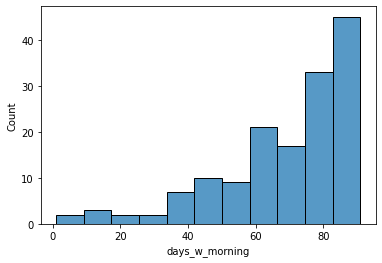

In [ ]:
sns.histplot(data=ema_compliance,x='days_w_morning')

In [ ]:
ema_compliance.query("subid==25").morning_inds.values[0]

array([ 0.,  2.,  3.,  4.,  5.,  7.,  8.,  9., 10., 11., 12., 13., 14.,
       15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27.,
       28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39., 40.,
       41., 42., 43., 44., 45., 46., 47., 48., 49., 51., 52., 53., 54.,
       55., 56., 57., 58., 59., 61., 62., 63., 64., 65., 66., 67., 68.,
       69., 70., 71., 72., 73., 74., 75., 76., 77., 78., 79., 80., 81.,
       82., 83., 84., 85., 86., 87., 88., 89.])

In [ ]:
# Featurizer helper function
def make_feats(labels,emas,subids):
    # Create the framework from the label dataset (just adding the feature columns to the existing label dataframe)
    df = labels.copy(deep=True)
    # Create the relevant columns and initialize to NaNs
    df[['ema_2','ema_3','ema_4','ema_5','ema_6','ema_7','ema_8','ema_9','ema_10',
        'lrm_ema_2','lrm_ema_3','lrm_ema_4','lrm_ema_5','lrm_ema_6','lrm_ema_7','lrm_ema_8','lrm_ema_9','lrm_ema_10',
        'srm_ema_2','srm_ema_3','srm_ema_4','srm_ema_5','srm_ema_6','srm_ema_7','srm_ema_8','srm_ema_9','srm_ema_10']]=np.nan#,
        #'d_lrm_ema_2','d_lrm_ema_3','d_lrm_ema_4','d_lrm_ema_5','d_lrm_ema_6','d_lrm_ema_7','d_lrm_ema_8','d_lrm_ema_9','d_lrm_ema_10']]=np.nan

    # Loop over the provided subids
    for id in subids:
        # Create a dataframe for this subject and filter to their morning EMAs
        sub_df = emas.query("subid==@id & ema_type=='morning'").copy(deep=True)
        study_days = range(90)
        # Loop over all days
        for day in study_days:
            # Further filter to days <= target day, with a descending sort (such that the first entry is the most recent)
            filt_df = sub_df.query("rounded_date==@day").copy()#.sort_values(by='norm_date',ascending=False)
            # Get the indices of the filtered dataframe
            idxs = df.query("subid==@id & day==@day").index.tolist()
            # Sanity check for multiple morning EMAs for this day
            if len(idxs)>1:
                print("ERROR on participant {}, day {}".format(id,day))
                break
            else:
                day_idx=idxs[0]
            # Get the relevant EMA values (look for the most recent non-NaN entries)
            # Generate a dummy row in rare cases where there is no data
            if filt_df.dropna(subset=['ema_2','ema_3','ema_4','ema_5','ema_6','ema_7','ema_8','ema_9','ema_10']).shape[0]==0:
                temp=filt_df.reindex([0])
                recent_vals = temp.iloc[0]
            else:
                recent_vals=filt_df.dropna(subset=['ema_2','ema_3','ema_4','ema_5','ema_6','ema_7','ema_8','ema_9','ema_10']).iloc[0]
            # Put these values into the dataframe in the correct row
            raw_vals = recent_vals[['ema_2','ema_3','ema_4','ema_5','ema_6','ema_7','ema_8','ema_9','ema_10']].tolist()
            df.loc[day_idx,['ema_2','ema_3','ema_4','ema_5','ema_6','ema_7','ema_8','ema_9','ema_10']]=raw_vals

            # Short run mean (SRM) values
            len_df = filt_df.shape[0]
            end_idx = min(len_df,3)
            if end_idx==0:
                temp=filt_df.reindex([0])
                srm_vals = temp.iloc[0]
            else:
                srm_vals = filt_df.iloc[0:end_idx][['ema_2','ema_3','ema_4','ema_5','ema_6','ema_7','ema_8','ema_9','ema_10']].mean().tolist()
            df.loc[day_idx,['srm_ema_2','srm_ema_3','srm_ema_4','srm_ema_5','srm_ema_6','srm_ema_7','srm_ema_8','srm_ema_9','srm_ema_10']]=srm_vals
            # Long run mean (LRM) values
            lrm_vals = filt_df[['ema_2','ema_3','ema_4','ema_5','ema_6','ema_7','ema_8','ema_9','ema_10']].mean().tolist()
            df.loc[day_idx,['lrm_ema_2','lrm_ema_3','lrm_ema_4','lrm_ema_5','lrm_ema_6','lrm_ema_7','lrm_ema_8','lrm_ema_9','lrm_ema_10']]=lrm_vals

            # Delta long run mean values
            #df.loc[day_idx,['d_lrm_ema_2','d_lrm_ema_3','d_lrm_ema_4','d_lrm_ema_5','d_lrm_ema_6','d_lrm_ema_7','d_lrm_ema_8','d_lrm_ema_9','d_lrm_ema_10']]=np.array(raw_vals)-np.array(lrm_vals)
    return df

# Make features, including a long-running arithmetic mean (from study start to present) and a short running arithmetic mean (last 3 morning EMA observations)
subids = ema_compliance.query("days_w_morning>=40").subid.unique()
feature_df = make_feats(day_labels.query("subid in @subids"),ema_df.query("subid in @subids"),subids)
feature_df.head()

,subid,day,lapse_count_d0,lapse_bool_d0,id_type,lapse_count,day_of_week_num_1,day_of_week_num_2,day_of_week_num_3,day_of_week_num_4,day_of_week_num_5,day_of_week_num_6,lapse_bool_d1,lapse_bool_d2,lapse_bool_d3,lapse_bool_d4,lapse_bool_d5,lapse_bool_d6,lapse_bool_d7,lapse_bool_d8,lapse_bool_d9,lapse_bool_d10,lapse_bool_d11,lapse_bool_d12,lapse_bool_d13,lapse_bool_d14,minus_1,minus_3,minus_5,lapse_bool_w0,lapse_bool_w1,lapse_bool_w2,lapse_bool_w3,lapse_bool_w4,lapse_bool_w5,lapse_bool_w6,lapse_bool_w7,ema_2,ema_3,ema_4,ema_5,ema_6,ema_7,ema_8,ema_9,ema_10,lrm_ema_2,lrm_ema_3,lrm_ema_4,lrm_ema_5,lrm_ema_6,lrm_ema_7,lrm_ema_8,lrm_ema_9,lrm_ema_10,srm_ema_2,srm_ema_3,srm_ema_4,srm_ema_5,srm_ema_6,srm_ema_7,srm_ema_8,srm_ema_9,srm_ema_10
0,1,0,0,0,0,0,0,0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,12.0,12.0,8.0,6.0,8.0,5.0,5.0,4.0,4.0,12.0,12.0,8.0,6.0,8.0,5.0,5.0,4.0,4.0,12.0,12.0,8.0,6.0,8.0,5.0,5.0,4.0
1,1,1,0,0,0,0,0,0,0,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,4.0,4.0,8.0,6.0,3.0,5.0,7.0,4.0,2.0,4.0,4.0,8.0,6.0,3.0,5.0,7.0,4.0,2.0,4.0,4.0,8.0,6.0,3.0,5.0,7.0,4.0
2,1,2,0,0,0,0,0,0,0,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,3,0,0,0,0,0,0,0,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,5.0,6.0,3.0,4.0,6.0,4.0,2.0,0.0,0.0,5.0,6.0,3.0,4.0,6.0,4.0,2.0,0.0,0.0,5.0,6.0,3.0,4.0,6.0,4.0
4,1,4,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,4.0,8.0,8.0,8.0,7.0,5.0,4.0,2.5,2.5,4.0,7.5,8.0,7.5,6.0,5.5,4.5,2.5,2.5,4.0,7.5,8.0,7.5,6.0,5.5,4.5


In [33]:
day_list = [0]+day_shift

day_test_labels = ['lapse_count_d0']+['lapse_bool_d'+str(i) for i in day_list]
week_test_labels = ['lapse_bool_w'+str(i) for i in week_shift]
misc_labels = ['subid','day','id_type','lapse_count']
minus_labels = ['minus_1','minus_3','minus_5']
ema_labels = ['ema_2','ema_3','ema_4','ema_5','ema_6','ema_7','ema_8','ema_9','ema_10']
srm_labels = ['srm_ema_2','srm_ema_3','srm_ema_4','srm_ema_5','srm_ema_6','srm_ema_7','srm_ema_8','srm_ema_9','srm_ema_10']
lrm_labels = ['lrm_ema_2','lrm_ema_3','lrm_ema_4','lrm_ema_5','lrm_ema_6','lrm_ema_7','lrm_ema_8','lrm_ema_9','lrm_ema_10']
dow_labels = ['day_of_week_num_1','day_of_week_num_2','day_of_week_num_3','day_of_week_num_4','day_of_week_num_5','day_of_week_num_6']

print(feature_df.shape)
#clean_feat = feature_df.dropna(subset=ema_labels+srm_labels+lrm_labels+dow_labels+minus_labels,axis=0)
clean_feat= feature_df.copy(deep=True)
print(clean_feat.shape)
clean_feat.head()
print(day_test_labels)

(12330, 64)
(12330, 64)
['lapse_count_d0', 'lapse_bool_d0', 'lapse_bool_d1', 'lapse_bool_d2', 'lapse_bool_d3', 'lapse_bool_d4', 'lapse_bool_d5', 'lapse_bool_d6', 'lapse_bool_d7', 'lapse_bool_d8', 'lapse_bool_d9', 'lapse_bool_d10', 'lapse_bool_d11', 'lapse_bool_d12', 'lapse_bool_d13', 'lapse_bool_d14']


In [ ]:
morning_only_labels = clean_feat.drop(columns=srm_labels+lrm_labels+minus_labels,axis=1)
morning_only_labels.head()

,subid,day,lapse_count_d0,lapse_bool_d0,id_type,lapse_count,day_of_week_num_1,day_of_week_num_2,day_of_week_num_3,day_of_week_num_4,day_of_week_num_5,day_of_week_num_6,lapse_bool_d1,lapse_bool_d2,lapse_bool_d3,lapse_bool_d4,lapse_bool_d5,lapse_bool_d6,lapse_bool_d7,lapse_bool_d8,lapse_bool_d9,lapse_bool_d10,lapse_bool_d11,lapse_bool_d12,lapse_bool_d13,lapse_bool_d14,lapse_bool_w0,lapse_bool_w1,lapse_bool_w2,lapse_bool_w3,lapse_bool_w4,lapse_bool_w5,lapse_bool_w6,lapse_bool_w7,ema_2,ema_3,ema_4,ema_5,ema_6,ema_7,ema_8,ema_9,ema_10
0,1,0,0,0,0,0,0,0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,12.0,12.0,8.0,6.0,8.0,5.0,5.0,4.0
1,1,1,0,0,0,0,0,0,0,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,4.0,4.0,8.0,6.0,3.0,5.0,7.0,4.0
2,1,2,0,0,0,0,0,0,0,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,3,0,0,0,0,0,0,0,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,5.0,6.0,3.0,4.0,6.0,4.0
4,1,4,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,4.0,8.0,8.0,8.0,7.0,5.0,4.0


In [51]:
# Export further deidentified list of values
error_list = [20,23,40,85,161,162,171]
# Select subjects with a minimum number of ema responses (morning)
#response_candidates = ema_compliance.query("days_w_morning>=60 & days_w_morning<91 & subid in @error_list").subid.unique()
response_candidates = ema_compliance.query("days_w_morning>=60 & days_w_morning<91").subid.unique()
print(response_candidates)

# Create a copy of the dataframe and add columns for scaled ema responses
training_raw = morning_only_labels.query("subid in @response_candidates").copy(deep=True)
training_raw["ema_2_scaled"]=training_raw["ema_2"]/12
training_raw["ema_3_scaled"]=training_raw["ema_3"]/12
training_raw["ema_4_scaled"]=training_raw["ema_4"]/12
training_raw["ema_5_scaled"]=training_raw["ema_5"]/12
training_raw["ema_6_scaled"]=(training_raw["ema_6"]-1)/10
training_raw["ema_7_scaled"]=(training_raw["ema_7"]-1)/10
training_raw["ema_8_scaled"]=(training_raw["ema_8"]-1)/10
training_raw["ema_9_scaled"]=(training_raw["ema_9"]-1)/10
training_raw["ema_10_scaled"]=(training_raw["ema_10"]-1)/10

# Columns to extract for use in parameter estimation
extract_cols = ['subid','day','ema_2_scaled','ema_3_scaled','ema_4_scaled','ema_5_scaled','ema_6_scaled','ema_7_scaled',
                'ema_8_scaled','ema_9_scaled','ema_10_scaled','lapse_bool_d0',
                'day_of_week_num_1','day_of_week_num_2','day_of_week_num_3','day_of_week_num_4','day_of_week_num_5','day_of_week_num_6']
training_df = training_raw[extract_cols]

# Add a reference column for how many emas that individual filled out
training_df['morning_ema']=np.nan

# Loop over each individual and reset their subject id
for i,id in enumerate(response_candidates):
    #training_df.loc[training_df.subid==id,'subid']=i
    info = ema_compliance.query('subid==@id')
    if info.shape[0]>1:
        print("ERROR")
    ema_count = info.days_w_morning.values[0]
    training_df.loc[training_df.subid==i,'morning_ema']=ema_count

# Reset the index overall and export to csv
training_df.reset_index(inplace=True,drop=True)
training_df.to_csv('subject_marss_60_90_covar.csv')

[  1   2   3   5   6   7   9  11  15  16  18  19  20  23  25  26  27  28
  29  30  32  33  34  37  38  39  40  42  43  44  48  51  52  53  54  58
  63  65  74  77  78  79  81  84  85  86  88  97  98  99 100 103 109 110
 118 119 121 128 130 131 134 135 136 137 138 139 143 149 150 158 161 162
 163 166 169 171 175 178 179 180 181 183 185 187 188 189 192 196 201 203
 208 211 213 214 215 222 223 224 225 230 234 236 238 240 241 242 243 248
 252 255 259 263 264 265 268 270]


/var/folders/yv/fz_ldjls7497yzp899r2yzw80000gn/T/ipykernel_14852/4174462052.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_df['morning_ema']=np.nan


In [ ]:

training=training_raw[extract_cols]
training.head()

training.to_csv('test_no_lapse_d.csv',index=False)
#training.to_csv('test_low_lapse',index=False)
#training.to_csv('test_high_lapse',index=False)

In [25]:
# Find a candidate individual
response_candidates = ema_compliance.query("days_w_morning>=90").subid.unique()
print(response_candidates)

lapse_candidates = morning_only_labels.query("lapse_count ==0").subid.unique()
print(lapse_candidates)

print(np.intersect1d(response_candidates,lapse_candidates))

# Select 230 for single lapse and full responsiveness
# Select 25 for 20 lapses and 86/90 responses
selection = 5
training_raw = morning_only_labels.query("subid == @selection").copy(deep=True)
response_days = ema_compliance.query("subid==@selection").morning_inds.values[0].astype(int)
#training_raw.head()
# Scale the EMA responses
training_raw["ema_2_scaled"]=training_raw["ema_2"]/12
training_raw["ema_3_scaled"]=training_raw["ema_3"]/12
training_raw["ema_4_scaled"]=training_raw["ema_4"]/12
training_raw["ema_5_scaled"]=training_raw["ema_5"]/12
training_raw["ema_6_scaled"]=(training_raw["ema_6"]-1)/10
training_raw["ema_7_scaled"]=(training_raw["ema_7"]-1)/10
training_raw["ema_8_scaled"]=(training_raw["ema_8"]-1)/10
training_raw["ema_9_scaled"]=(training_raw["ema_9"]-1)/10
training_raw["ema_10_scaled"]=(training_raw["ema_10"]-1)/10
display(training_raw.iloc[0:30])

[  5   9 162 230]
[  1   5   6   9  15  18  21  23  28  29  30  31  32  40  44  63  64  66
  74  88  94  99 103 130 134 135 136 138 139 143 156 162 163 167 171 179
 181 183 187 188 190 192 196 197 200 201 203 208 209 215 222 223 224 238
 240 242 245 248 252 255 259 262 264]
[  5   9 162]


,subid,day,lapse_count_d0,lapse_bool_d0,id_type,lapse_count,day_of_week_num_1,day_of_week_num_2,day_of_week_num_3,day_of_week_num_4,day_of_week_num_5,day_of_week_num_6,lapse_bool_d1,lapse_bool_d2,lapse_bool_d3,lapse_bool_d4,lapse_bool_d5,lapse_bool_d6,lapse_bool_d7,lapse_bool_d8,lapse_bool_d9,lapse_bool_d10,lapse_bool_d11,lapse_bool_d12,lapse_bool_d13,lapse_bool_d14,lapse_bool_w0,lapse_bool_w1,lapse_bool_w2,lapse_bool_w3,lapse_bool_w4,lapse_bool_w5,lapse_bool_w6,lapse_bool_w7,ema_2,ema_3,ema_4,ema_5,ema_6,ema_7,ema_8,ema_9,ema_10,ema_2_scaled,ema_3_scaled,ema_4_scaled,ema_5_scaled,ema_6_scaled,ema_7_scaled,ema_8_scaled,ema_9_scaled,ema_10_scaled
270,5,0,0,0,0,0,1,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0,4.0,7.0,2.0,8.0,8.0,2.0,0.083333,0.000000,0.416667,0.333333,0.6,0.1,0.7,0.7,0.1
271,5,1,0,0,0,0,0,1,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,7.0,7.0,2.0,4.0,10.0,2.0,0.000000,0.000000,0.666667,0.583333,0.6,0.1,0.3,0.9,0.1
272,5,2,0,0,0,0,0,0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0,9.0,8.0,9.0,3.0,10.0,10.0,2.0,0.416667,0.166667,0.750000,0.666667,0.8,0.2,0.9,0.9,0.1
273,5,3,0,0,0,0,0,0,0,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,2.0,2.0,1.0,10.0,10.0,1.0,0.000000,0.000000,0.500000,0.166667,0.1,0.0,0.9,0.9,0.0
274,5,4,0,0,0,0,0,0,0,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,9.0,9.0,9.0,2.0,10.0,10.0,1.0,0.083333,0.333333,0.750000,0.750000,0.8,0.1,0.9,0.9,0.0
275,5,5,0,0,0,0,0,0,0,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,9.0,6.0,8.0,2.0,10.0,9.0,1.0,0.000000,0.333333,0.750000,0.500000,0.7,0.1,0.9,0.8,0.0
276,5,6,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,5.0,10.0,8.0,9.0,2.0,10.0,10.0,1.0,0.333333,0.416667,0.833333,0.666667,0.8,0.1,0.9,0.9,0.0
277,5,7,0,0,0,0,1,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,7.0,10.0,2.0,3.0,3.0,7.0,9.0,1.0,0.500000,0.583333,0.833333,0.166667,0.2,0.2,0.6,0.8,0.0
278,5,8,0,0,0,0,0,1,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,8.0,8.0,3.0,9.0,9.0,8.0,4.0,8.0,0.750000,0.666667,0.666667,0.250000,0.8,0.8,0.7,0.3,0.7
279,5,9,0,0,0,0,0,0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,10.0,11.0,10.0,11.0,9.0,10.0,1.0,0.083333,0.166667,0.833333,0.916667,0.9,1.0,0.8,0.9,0.0


In [26]:
extract_cols = ['day','ema_2_scaled','ema_3_scaled','ema_4_scaled','ema_5_scaled','ema_6_scaled','ema_7_scaled',
                'ema_8_scaled','ema_9_scaled','ema_10_scaled','lapse_bool_d0']
training=training_raw[extract_cols]
training.head()

training.to_csv('test_no_lapse_d.csv',index=False)
#training.to_csv('test_low_lapse',index=False)
#training.to_csv('test_high_lapse',index=False)

<AxesSubplot:xlabel='day', ylabel='lapse_bool_d0'>

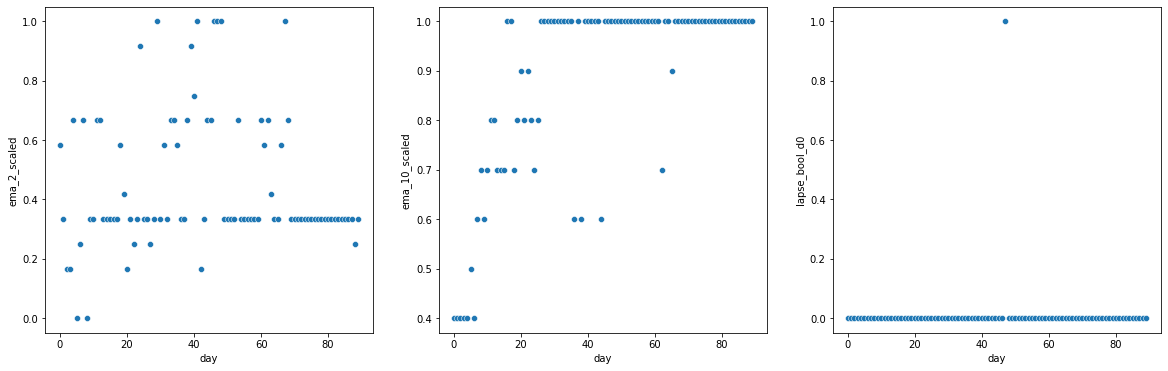

In [17]:
fig,ax = plt.subplots(nrows=1,ncols=3,figsize=(20,6))
sns.scatterplot(ax=ax[0],data=training_raw,x='day',y='ema_2_scaled')
sns.scatterplot(ax=ax[1],data=training_raw,x='day',y='ema_10_scaled')
sns.scatterplot(ax=ax[2],data=training_raw,x='day',y='lapse_bool_d0')

In [18]:
# Create two scalar optimization variables.
x = cp.Variable()
y = cp.Variable()

# Create two constraints.
constraints = [x + y == 1,
               x - y >= 1]

# Form objective.
obj = cp.Minimize((x - y)**2)

# Form and solve problem.
prob = cp.Problem(obj, constraints)
prob.solve()  # Returns the optimal value.
print("status:", prob.status)
print("optimal value", prob.value)
print("optimal var", x.value, y.value)

status: optimal
optimal value 1.0
optimal var 1.0 3.50057026691824e-30


In [19]:
var10 = np.var(training_raw.ema_10_scaled)
print(var10)
var2 = np.var(training_raw.ema_2_scaled)
print(var2)
mean10 = np.mean(training_raw.ema_10_scaled)
print(mean10)

0.034320987654320984
0.05136231138545954
0.8888888888888888


In [20]:
np.linspace(mean10-.1,mean10+.1,3)

array([0.78888889, 0.88888889, 0.98888889])

In [21]:
a = cp.Variable()
x = cp.Variable(90)
c = cp.Parameter(nonneg=True)
delta = 0.001
constraints = [x >= delta,
               x <= 1-delta]
for c_val in np.linspace(mean10-.1,mean10+.1,3):
    print(c_val)
    c.value = c_val
    obj = cp.Minimize(cp.sum(c-x))

0.7888888888888889
0.8888888888888888
0.9888888888888888


In [22]:
import gurobipy as gp
import numpy as np
from gurobipy import GRB
from scipy import stats

In [23]:
days = np.arange(90)+1
print(days)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90]


In [24]:
y=training_raw.ema_10_scaled.tolist()
print(y)
d=training_raw.lapse_bool_d0.tolist()
print(d)

[0.4, 0.4, 0.4, 0.4, 0.4, 0.5, 0.4, 0.6, 0.7, 0.6, 0.7, 0.8, 0.8, 0.7, 0.7, 0.7, 1.0, 1.0, 0.7, 0.8, 0.9, 0.8, 0.9, 0.8, 0.7, 0.8, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.6, 1.0, 0.6, 1.0, 1.0, 1.0, 1.0, 1.0, 0.6, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.7, 1.0, 1.0, 0.9, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [25]:
days[:-1]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89])

In [101]:
# Model parameters
delta = 0.00001
y10=training_raw.ema_10_scaled.tolist()
y2=training_raw.ema_2_scaled.tolist()

a10=2
a2=2
b=0.9
xivar = 0.01
lapse_weight = 100
# Create the base model
m = gp.Model('bivariate')

# Add variables
x = m.addVars(days,lb=delta,ub=1-delta, name="x")
xc = m.addVars(days,lb=delta,ub=1-delta, name="xcomplement")
c10 = m.addVar(lb=-100,ub=100,name='c10')
c2 = m.addVar(lb=-100,ub=100,name='c2')
eps10 = m.addVars(days,lb=-GRB.INFINITY, name="obs_noise10")
eps2 = m.addVars(days,lb=-GRB.INFINITY, name="obs_noise2")
xi = m.addVars(days,lb=-GRB.INFINITY, name='tran_noise')
lognl = m.addVars(days,lb=-GRB.INFINITY,ub=0, name='logapprox_nolapse')
logl = m.addVars(days,lb=-GRB.INFINITY,ub=0, name='logapprox_lapse')

# Set objective
m.setObjective(
    sum(0.5/var10*(eps10[t])**2+0.5/var2*(eps2[t])**2
        -(1-d[t-1])*lognl[t]-d[t-1]*logl[t] for t in days)
    + sum(0.5*np.log(xivar)+0.5/xivar*(xi[t])**2 for t in days[:-1]), GRB.MINIMIZE)

# Set constraints
m.addConstrs(eps10[t]==y10[t-1]-a10*x[t]-c10 for t in days)
m.addConstrs(eps2[t]==y2[t-1]-a2*x[t]-c2 for t in days)
m.addConstrs(xi[t]==x[t+1]-b*x[t] for t in days[:-1])
m.addConstrs(xc[t]==1-x[t] for t in days)
for t in days:
    m.addGenConstrLog(xc[t],lognl[t],"FuncPieces=5")
    m.addGenConstrLog(x[t],logl[t],"FuncPieces=5")

# Optimize
m.optimize()

# Print stuff
for v in m.getVars():
    print('%s %g' % (v.varName, v.x))
print('Obj: %g' % m.objVal)


Gurobi Optimizer version 9.5.1 build v9.5.1rc2 (mac64[arm])
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 359 rows, 632 columns and 987 nonzeros
Model fingerprint: 0x76953634
Model has 269 quadratic objective terms
Model has 180 general constraints
Variable types: 632 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [9e-01, 2e+00]
  Objective range  [1e+00, 1e+00]
  QObjective range [2e+01, 1e+02]
  Bounds range     [1e-05, 1e+02]
  RHS range        [2e-01, 1e+00]
Presolve added 360 rows and 19079 columns
Presolve time: 0.02s
Presolved: 719 rows, 19711 columns, 49227 nonzeros
Presolved model has 180 SOS constraint(s)
Presolved model has 269 quadratic objective terms
Variable types: 19711 continuous, 0 integer (0 binary)

Root relaxation: objective -1.418125e+02, 21612 iterations, 0.39 seconds (1.32 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Dept

<AxesSubplot:xlabel='day', ylabel='lapse_bool_d0'>

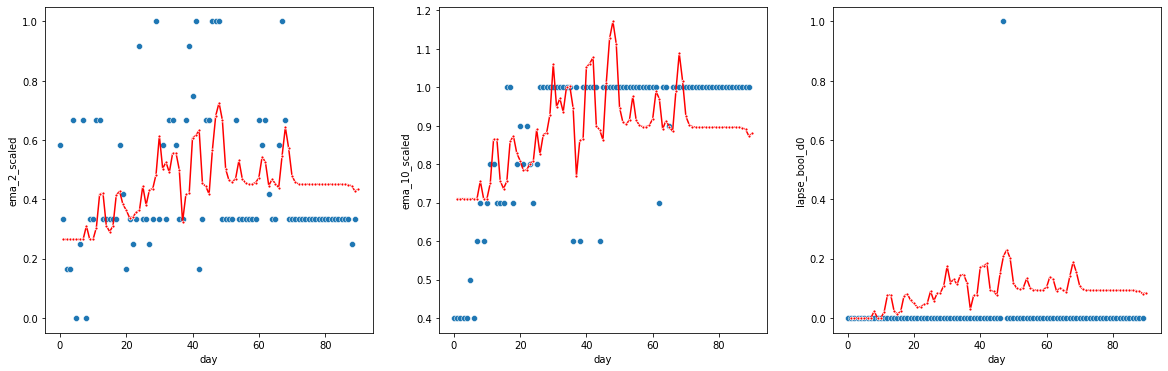

In [100]:
# Test plotting
testing = m.getAttr('x',x)
xvals = np.array([testing[i] for i in testing.keys()])
c10val = c10.x
c2val = c2.x
y10vals = a10*xvals+c10val
y2vals = a2*xvals+c2val

fig,ax = plt.subplots(nrows=1,ncols=3,figsize=(20,6))
sns.scatterplot(ax=ax[0],data=training_raw,x='day',y='ema_2_scaled')
sns.lineplot(ax=ax[0],x=days,y=y2vals,color='r',marker='.')
sns.scatterplot(ax=ax[1],data=training_raw,x='day',y='ema_10_scaled')
sns.lineplot(ax=ax[1],x=days,y=y10vals,color='r',marker='.')
sns.scatterplot(ax=ax[2],data=training_raw,x='day',y='lapse_bool_d0')
sns.lineplot(ax=ax[2],x=days,y=xvals,color='r',marker='.')

In [209]:
print(res_days)

[ 1.  3.  4.  5.  6.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20.
 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36. 37. 38.
 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 52. 53. 54. 55. 56. 57.
 58. 59. 60. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71. 72. 73. 74. 75. 76.
 77. 78. 79. 80. 81. 82. 83. 84. 85. 86. 87. 88. 89. 90.]


In [217]:
# Model parameters
delta = 0.00001
y2=np.array(training_raw.ema_2_scaled.tolist())
#print(np.var(y2))
y7=np.array(training_raw.ema_7_scaled.tolist())
#print(np.var(y7))
y8=np.array(training_raw.ema_8_scaled.tolist())
#print(np.var(y8))
y10=np.array(training_raw.ema_10_scaled.tolist())
#print(np.var(y10))

y=np.stack([y2,y7,y8,y10])
covy=np.cov(y)
covy_inv=np.linalg.inv(covy)
det_covy=np.linalg.det(covy)
#print(covy)
#print(covy_inv)
#print(det_covy)

a2=5
a7=5
a8=6
a10=7
a = np.stack([a2,a7,a8,a10])
#print(a)
#print(a.size)
days = np.arange(90)+1
res_days = response_days + 1
b=0.9
xivar = 0.5
lapse_weight = 1
zero_ind_days = np.arange(90)
# Create the base model
m = gp.Model('generalized vector')

# Add variables
x = m.addVars(days,lb=delta,ub=1-delta, name="x")
xc = m.addVars(days,lb=delta,ub=1-delta, name="xcomplement")
c = m.addVars(range(a.size),lb=-100,ub=100,name='c')
eps = m.addVars(range(a.size),res_days,lb=-GRB.INFINITY, name="obs_noise")
xi = m.addVars(days,lb=-GRB.INFINITY, name='tran_noise')
lognl = m.addVars(days,lb=-GRB.INFINITY,ub=0, name='logapprox_nolapse')
logl = m.addVars(days,lb=-GRB.INFINITY,ub=0, name='logapprox_lapse')

# Set objective
m.setObjective(
    sum(0.5*(sum(eps[i,t]*sum(covy_inv[i,j]*eps[j,t] for j in range(a.size)) for i in range(a.size))) for t in res_days)
    +sum(-(1-d[t-1])*lognl[t]-lapse_weight*d[t-1]*logl[t] for t in days)
    + sum(0.5*np.log(xivar)+0.5/xivar*(xi[t])**2 for t in days[:-1]), GRB.MINIMIZE)

# Set constraints
m.addConstrs(eps[i,t]==y[i,t-1]-a[i]*x[t]-c[i] for i in range(a.size) for t in res_days)
m.addConstrs(xi[t]==x[t+1]-b*x[t] for t in days[:-1])
m.addConstrs(xc[t]==1-x[t] for t in days)
for t in days:
    m.addGenConstrLog(xc[t],lognl[t],"FuncPieces=5")
    m.addGenConstrLog(x[t],logl[t],"FuncPieces=5")

# Optimize
m.optimize()

# Print stuff
for v in m.getVars():
    print('%s %g' % (v.varName, v.x))
print('Obj: %g' % m.objVal)

Gurobi Optimizer version 9.5.1 build v9.5.1rc2 (mac64[arm])
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 523 rows, 798 columns and 1479 nonzeros
Model fingerprint: 0x3a6f0e81
Model has 949 quadratic objective terms
Model has 180 general constraints
Variable types: 798 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [9e-01, 7e+00]
  Objective range  [1e+00, 1e+00]
  QObjective range [2e+00, 4e+01]
  Bounds range     [1e-05, 1e+02]
  RHS range        [8e-02, 1e+00]
Presolve added 360 rows and 19079 columns
Presolve time: 0.02s
Presolved: 883 rows, 19877 columns, 49719 nonzeros
Presolved model has 180 SOS constraint(s)
Presolved model has 949 quadratic objective terms
Variable types: 19877 continuous, 0 integer (0 binary)

Root relaxation: objective 1.014976e+02, 13600 iterations, 0.29 seconds (0.93 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Dept

(4, 90)


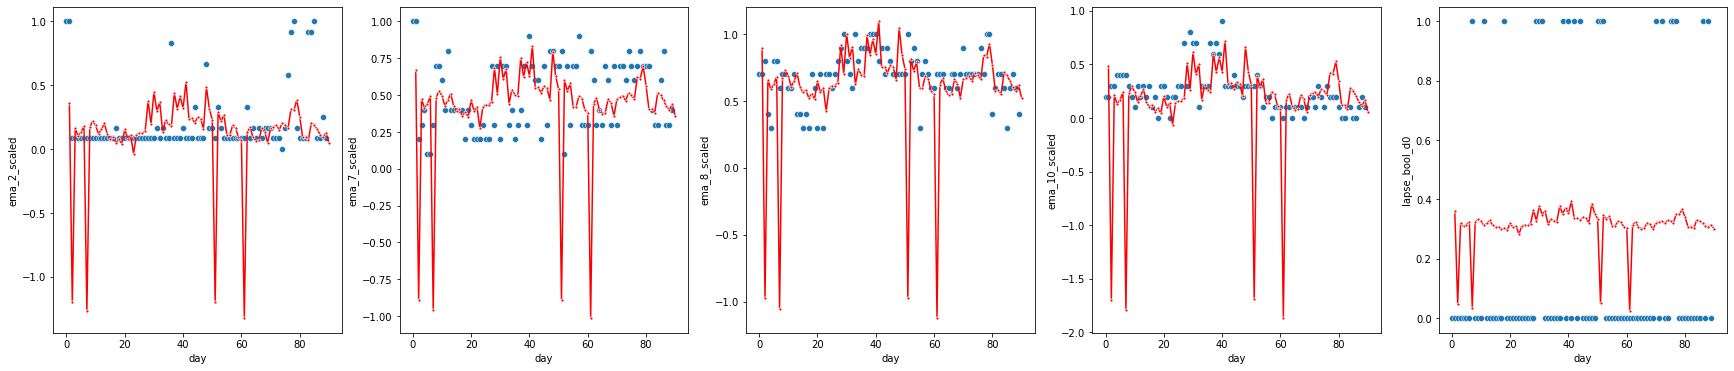

In [216]:
# Test plotting
xraw = m.getAttr('x',x)
xvals = np.array([xraw[i] for i in xraw.keys()])
craw = m.getAttr('x',c)
cvals= np.array([craw[i] for i in craw.keys()])
yout=np.outer(a,xvals)+np.tile(cvals,(xvals.size,1)).T
print(yout.shape)

fig,ax = plt.subplots(nrows=1,ncols=a.size+1,figsize=(30,6))
sns.scatterplot(ax=ax[0],data=training_raw,x='day',y='ema_2_scaled')
sns.scatterplot(ax=ax[1],data=training_raw,x='day',y='ema_7_scaled')
sns.scatterplot(ax=ax[2],data=training_raw,x='day',y='ema_8_scaled')
sns.scatterplot(ax=ax[3],data=training_raw,x='day',y='ema_10_scaled')
sns.scatterplot(ax=ax[4],data=training_raw,x='day',y='lapse_bool_d0')
for i in range(a.size):
    sns.lineplot(ax=ax[i],x=days,y=yout[i,:],color='r',marker='.')
sns.lineplot(ax=ax[a.size],x=days,y=xvals,color='r',marker='.')
None

In [47]:
import optuna
def objective(trial,delta,y10,y2):
    a10=trial.suggest_float('a10',0,25)
    a2=trial.suggest_float('a2',0,25)
    b=trial.suggest_float('b',0.7,1.3)
    xivar = 0.05
    #print(a10,a2,b)
    objval = get_obj_val(delta,y10,y2,a10,a2,b,xivar)
    return objval

def get_obj_val(delta,y10,y2,a10,a2,b,xivar):
    var10 = np.var(y10)
    var2 = np.var(y2)

    # Create the base model
    m = gp.Model('bivariate')
    m.setParam('OutputFlag',False)
    m.setParam('LogToConsole',False)
    # Add variables
    x = m.addVars(days,lb=delta,ub=1-delta, name="x")
    xc = m.addVars(days,lb=delta,ub=1-delta, name="xcomplement")
    c10 = m.addVar(lb=-2,ub=2,name='c10')
    c2 = m.addVar(lb=-2,ub=2,name='c2')
    eps10 = m.addVars(days,lb=-GRB.INFINITY, name="obs_noise10")
    eps2 = m.addVars(days,lb=-GRB.INFINITY, name="obs_noise2")
    xi = m.addVars(days,lb=-GRB.INFINITY, name='tran_noise')
    lognl = m.addVars(days,lb=-GRB.INFINITY,ub=0, name='logapprox_nolapse')
    logl = m.addVars(days,lb=-GRB.INFINITY,ub=0, name='logapprox_lapse')

    # Set objective
    m.setObjective(
        sum(0.5/var10*(eps10[t])**2+0.5/var2*(eps2[t])**2
            -(1-d[t-1])*lognl[t]-d[t-1]*logl[t] for t in days)
        + sum(0.5*np.log(xivar)+0.5/xivar*(xi[t])**2 for t in days[:-1]), GRB.MINIMIZE)

    # Set constraints
    m.addConstrs(eps10[t]==y10[t-1]-a10*(x[t]-c10) for t in days)
    m.addConstrs(eps2[t]==y2[t-1]-a2*(x[t]-c2) for t in days)
    m.addConstrs(xi[t]==x[t+1]-b*x[t] for t in days[:-1])
    m.addConstrs(xc[t]==1-x[t] for t in days)
    for t in days:
        m.addGenConstrLog(xc[t],lognl[t],"FuncPieces=5")
        m.addGenConstrLog(x[t],logl[t],"FuncPieces=5")

    # Optimize
    m.optimize()

    return m.objVal


In [48]:
# Core model parameters
delta = 0.00001
y10=training_raw.ema_10_scaled.tolist()
y2=training_raw.ema_2_scaled.tolist()

study_name = "initial_testing_xivar_0_05_testing"
storage_name = "sqlite:///{}{}.db".format("/Users/eric/repos/aud/optuna/",study_name)
study = optuna.create_study(study_name=study_name,storage=storage_name,direction = "minimize",load_if_exists=True)
study.optimize(lambda trial: objective(trial,delta,y10,y2),n_trials=100)

print("Study statistics: ")
print("  Number of finished trials: ", len(study.trials))

print("Best trial:")
trial = study.best_trial

print("  Value: ", trial.value)
print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

[I 2024-01-02 22:06:32,697] A new study created in RDB with name: initial_testing_xivar_0_05_testing
[I 2024-01-02 22:07:04,148] Trial 0 finished with value: -85.808687723325 and parameters: {'a10': 4.709080370347224, 'a2': 13.754142484304769, 'b': 0.9347338010862307}. Best is trial 0 with value: -85.808687723325.
[I 2024-01-02 22:07:35,745] Trial 1 finished with value: -85.20722050477787 and parameters: {'a10': 3.824296152242615, 'a2': 21.36956998776758, 'b': 0.9592817658282203}. Best is trial 0 with value: -85.808687723325.
[I 2024-01-02 22:08:13,617] Trial 2 finished with value: -87.48963560867966 and parameters: {'a10': 18.22148874873554, 'a2': 16.50677854686758, 'b': 0.8958530324758824}. Best is trial 2 with value: -87.48963560867966.
[I 2024-01-02 22:08:43,514] Trial 3 finished with value: -87.20299236268214 and parameters: {'a10': 9.958176453064002, 'a2': 17.57526794207554, 'b': 1.228079370411183}. Best is trial 2 with value: -87.48963560867966.
[I 2024-01-02 22:09:17,183] Trial

Study statistics: 
  Number of finished trials:  100
Best trial:
  Value:  -87.94231915892476
  Params: 
    a10: 19.84133796058955
    a2: 24.895990070013266
    b: 0.8445723661037473


In [235]:
# General vector optimization
import optuna
def objective(trial,delta,y,d,days,res_days):
    a2=trial.suggest_float('a2',0,25)
    a7=trial.suggest_float('a7',0,25)
    a8=trial.suggest_float('a8',0,25)
    a10=trial.suggest_float('a10',0,25)
    a = np.stack([a2,a7,a8,a10])
    b=trial.suggest_float('b',0.7,1.2)
    xivar = 0.05
    objval = get_obj_val(delta,y,a,b,xivar,d,days,res_days)
    return objval

def get_obj_val(delta,y,a,b,xivar,d,days,res_days):
    covy = np.cov(y)
    covy_inv=np.linalg.inv(covy)

    # Create the base model
    m = gp.Model('generalized vector')
    m.setParam('OutputFlag',False)
    m.setParam('LogToConsole',False)

    # Add variables
    x = m.addVars(days,lb=delta,ub=1-delta, name="x")
    xc = m.addVars(days,lb=delta,ub=1-delta, name="xcomplement")
    c = m.addVars(range(a.size),lb=-100,ub=100,name='c')
    eps = m.addVars(range(a.size),res_days,lb=-GRB.INFINITY, name="obs_noise")
    xi = m.addVars(days,lb=-GRB.INFINITY, name='tran_noise')
    lognl = m.addVars(days,lb=-GRB.INFINITY,ub=0, name='logapprox_nolapse')
    logl = m.addVars(days,lb=-GRB.INFINITY,ub=0, name='logapprox_lapse')

    # Set objective
    m.setObjective(
        sum(0.5*(sum(eps[i,t]*sum(covy_inv[i,j]*eps[j,t] for j in range(a.size)) for i in range(a.size))) for t in res_days)
        +sum(-(1-d[t-1])*lognl[t]-d[t-1]*logl[t] for t in days)
        + sum(0.5*np.log(xivar)+0.5/xivar*(xi[t])**2 for t in days[:-1]), GRB.MINIMIZE)

    # Set constraints
    m.addConstrs(eps[i,t]==y[i,t-1]-a[i]*x[t]-c[i] for i in range(a.size) for t in res_days)
    m.addConstrs(xi[t]==x[t+1]-b*x[t] for t in days[:-1])
    m.addConstrs(xc[t]==1-x[t] for t in days)
    for t in days:
        m.addGenConstrLog(xc[t],lognl[t],"FuncPieces=5")
        m.addGenConstrLog(x[t],logl[t],"FuncPieces=5")

    # Optimize
    m.optimize()

    return m.objVal

# Core model parameters
delta = 0.00001
days = np.arange(90)+1
res_days = response_days + 1

y2=np.array(training_raw.ema_2_scaled.tolist())
#print(np.var(y2))
y7=np.array(training_raw.ema_7_scaled.tolist())
#print(np.var(y7))
y8=np.array(training_raw.ema_8_scaled.tolist())
#print(np.var(y8))
y10=np.array(training_raw.ema_10_scaled.tolist())
#print(np.var(y10))
y=np.stack([y2,y7,y8,y10])
d=np.array(training_raw.lapse_bool_d0.tolist()).astype(int)

study_name = "covariance_testing_xivar_0_05_alt"
storage_name = "sqlite:///{}{}.db".format("/Users/eric/repos/aud/optuna/",study_name)
study = optuna.create_study(study_name=study_name,storage=storage_name,direction = "minimize",load_if_exists=True)
study.optimize(lambda trial: objective(trial,delta,y,d,days,res_days),n_trials=20)

print("Study statistics: ")
print("  Number of finished trials: ", len(study.trials))

print("Best trial:")
trial = study.best_trial

print("  Value: ", trial.value)
print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

[I 2024-01-03 14:07:34,027] A new study created in RDB with name: covariance_testing_xivar_0_05_alt
[I 2024-01-03 14:08:19,862] Trial 0 finished with value: 40.769222991293134 and parameters: {'a2': 5.618610477079475, 'a7': 8.042645486593381, 'a8': 1.7560700128877726, 'a10': 18.738145525308855, 'b': 0.7863942162112496}. Best is trial 0 with value: 40.769222991293134.
[I 2024-01-03 14:09:23,583] Trial 1 finished with value: 43.34050978459666 and parameters: {'a2': 21.404257683844047, 'a7': 18.683532369183773, 'a8': 15.145315033783586, 'a10': 16.575105478602417, 'b': 0.7766123376014717}. Best is trial 0 with value: 40.769222991293134.
[I 2024-01-03 14:10:17,036] Trial 2 finished with value: 38.39858247764002 and parameters: {'a2': 0.4253582714456777, 'a7': 7.4374176830117715, 'a8': 19.693077947826826, 'a10': 23.09587641207235, 'b': 0.9880940381417044}. Best is trial 2 with value: 38.39858247764002.
[I 2024-01-03 14:11:31,098] Trial 3 finished with value: 41.010520977673536 and parameters

Study statistics: 
  Number of finished trials:  20
Best trial:
  Value:  38.172243794301835
  Params: 
    a10: 12.674936182693845
    a2: 0.8687281577066686
    a7: 3.4474201551711157
    a8: 18.93535731899869
    b: 1.0265599992117531


In [30]:
from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_slice

In [223]:
plot_optimization_history(study)

In [224]:
plot_parallel_coordinate(study)

In [225]:
plot_contour(study)

Gurobi Optimizer version 9.5.1 build v9.5.1rc2 (mac64[arm])
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 523 rows, 798 columns and 1479 nonzeros
Model fingerprint: 0x84b846ee
Model has 949 quadratic objective terms
Model has 180 general constraints
Variable types: 798 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [0e+00, 0e+00]
  QObjective range [3e+00, 4e+01]
  Bounds range     [1e-05, 1e+02]
  RHS range        [8e-02, 1e+00]
Presolve added 270 rows and 18989 columns
Presolve time: 0.01s
Presolved: 793 rows, 19787 columns, 39999 nonzeros
Presolved model has 180 SOS constraint(s)
Presolved model has 949 quadratic objective terms
Variable types: 19787 continuous, 0 integer (0 binary)

Root relaxation: objective -8.485571e+00, 1620 iterations, 0.03 seconds (0.07 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Dept

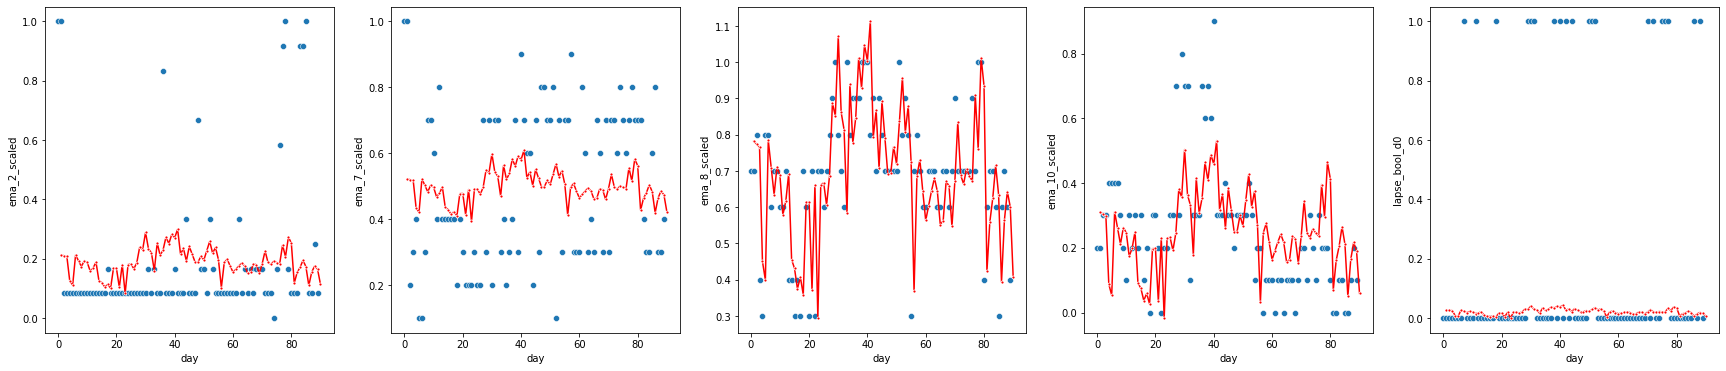

In [239]:
# Model parameters
delta = 0.00001
y2=np.array(training_raw.ema_2_scaled.tolist())
#print(np.var(y2))
y7=np.array(training_raw.ema_7_scaled.tolist())
#print(np.var(y7))
y8=np.array(training_raw.ema_8_scaled.tolist())
#print(np.var(y8))
y10=np.array(training_raw.ema_10_scaled.tolist())
#print(np.var(y10))
d=np.array(training_raw.lapse_bool_d0.tolist())

y=np.stack([y2,y7,y8,y10])
covy=np.cov(y)
covy_inv=np.linalg.inv(covy)

a2=5
a7=5
a8=18.94
a10=12.7
a = np.stack([a2,a7,a8,a10])
#print(a)
#print(a.size)
days = np.arange(90)+1
res_days = response_days + 1
b=1.03
xivar = 0.05
lapse_weight = 1
zero_ind_days = np.arange(90)
# Create the base model
m = gp.Model('generalized vector')

# Add variables
x = m.addVars(days,lb=delta,ub=1-delta, name="x")
xc = m.addVars(days,lb=delta,ub=1-delta, name="xcomplement")
c = m.addVars(range(a.size),lb=-100,ub=100,name='c')
eps = m.addVars(range(a.size),res_days,lb=-GRB.INFINITY, name="obs_noise")
xi = m.addVars(days,lb=-GRB.INFINITY, name='tran_noise')
lognl = m.addVars(days,lb=-GRB.INFINITY,ub=0, name='logapprox_nolapse')
logl = m.addVars(days,lb=-GRB.INFINITY,ub=0, name='logapprox_lapse')

# Set objective
m.setObjective(
    sum(0.5*(sum(eps[i,t]*sum(covy_inv[i,j]*eps[j,t] for j in range(a.size)) for i in range(a.size))) for t in res_days)
    +sum(-(1-d[t-1])*lognl[t]-lapse_weight*d[t-1]*logl[t] for t in days)
    +sum(0.5*np.log(xivar)+0.5/xivar*(xi[t])**2 for t in days[:-1]), GRB.MINIMIZE)

# Set constraints
m.addConstrs(eps[i,t]==y[i,t-1]-a[i]*x[t]-c[i] for i in range(a.size) for t in res_days)
m.addConstrs(xi[t]==x[t+1]-b*x[t] for t in days[:-1])
m.addConstrs(xc[t]==1-x[t] for t in days)
for t in days:
    m.addGenConstrLog(xc[t],lognl[t],"FuncPieces=5")
    m.addGenConstrLog(x[t],logl[t],"FuncPieces=5")

# Optimize
m.optimize()

# Print stuff
for v in m.getVars():
    print('%s %g' % (v.varName, v.x))
print('Obj: %g' % m.objVal)

# Test plotting
xraw = m.getAttr('x',x)
xvals = np.array([xraw[i] for i in xraw.keys()])
craw = m.getAttr('x',c)
cvals= np.array([craw[i] for i in craw.keys()])
yout=np.outer(a,xvals)+np.tile(cvals,(xvals.size,1)).T
print(yout.shape)

fig,ax = plt.subplots(nrows=1,ncols=a.size+1,figsize=(30,6))
sns.scatterplot(ax=ax[0],data=training_raw,x='day',y='ema_2_scaled')
sns.scatterplot(ax=ax[1],data=training_raw,x='day',y='ema_7_scaled')
sns.scatterplot(ax=ax[2],data=training_raw,x='day',y='ema_8_scaled')
sns.scatterplot(ax=ax[3],data=training_raw,x='day',y='ema_10_scaled')
sns.scatterplot(ax=ax[4],data=training_raw,x='day',y='lapse_bool_d0')
for i in range(a.size):
    sns.lineplot(ax=ax[i],x=days,y=yout[i,:],color='r',marker='.')
sns.lineplot(ax=ax[a.size],x=days,y=xvals,color='r',marker='.')
None